In [ ]:
!pip install kaleido==0.1.0

In [ ]:
!python -m pip install pandas corus nltk scikit-learn seaborn matplotlib gensim navec pymorphy3 bertopic sentence-transformers umap-learn hdbscan gensim

In [3]:
import os
import re
import urllib.request
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from corus import load_lenta
from gensim.models import KeyedVectors, Word2Vec
from hdbscan import HDBSCAN
from navec import Navec
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import pymorphy3
from sentence_transformers import SentenceTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from umap import UMAP
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from IPython.display import display, Image

In [4]:
RANDOM_STATE = 52

In [ ]:
nltk.download('stopwords')

In [ ]:
!curl -L -O https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

# EDA (взял предобработку с ЛР1-2)

In [7]:
path = 'lenta-ru-news.csv.gz'
records = load_lenta(path)

data =[]
for record in records:
    data.append({
        'title': record.title,
        'text': record.text,
        'topic': record.topic
    })

df = pd.DataFrame(data)

Посмотрим сколько у нас пустых топиков и удалим их

In [8]:
initial_count = len(df)
print(f"Всего записей {initial_count}")

df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

print("\nПропуски")
print(df.isna().sum())

Всего записей 739351

Пропуски
title      0
text       5
topic    203
dtype: int64


In [9]:
df = df.dropna(subset=['topic'])

Посмотрим на распределение новостей по каждой теме

topic
Россия               160519
Мир                  136680
Экономика             79538
Спорт                 64421
Культура              53803
Бывший СССР           53402
Наука и техника       53136
Интернет и СМИ        44675
Из жизни              27611
Дом                   21734
Силовые структуры     19596
Ценности               7766
Бизнес                 7399
Путешествия            6408
69-я параллель         1268
Крым                    666
Культпросвет            340
Легпром                 114
Библиотека               65
Оружие                    3
ЧМ-2014                   2
МедНовости                1
Сочи                      1
Name: count, dtype: int64


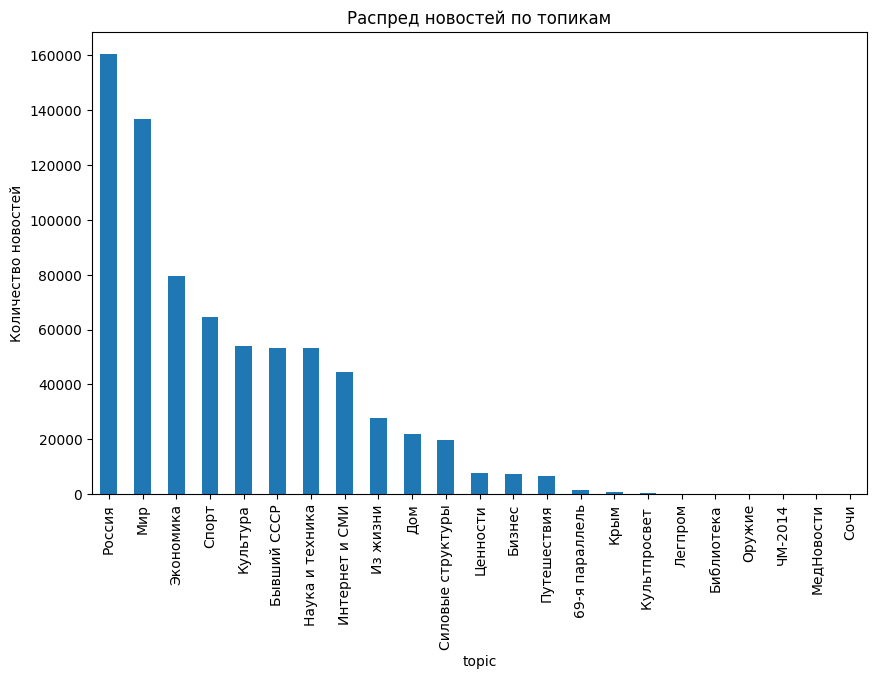

In [10]:
topic_counts = df['topic'].value_counts()
print(topic_counts)

plt.figure(figsize=(10, 6))
topic_counts.plot(kind='bar')
plt.title('Распред новостей по топикам')
plt.ylabel('Количество новостей')
plt.show()

Мне часто высвечивался warning при разделении данных в сплитах, мол слишком мало новостей для какого-то топика (stratify жаловался). Принял решение отсеять топики по кол-ву новостей

In [11]:
counts = df['topic'].value_counts()
valid_topics = counts[counts >= 100].index

df_clean = df[df['topic'].isin(valid_topics)]

print("Размер", df_clean.shape)

Размер (739076, 3)


Возьмем 100к

In [12]:
df_sample, _ = train_test_split(
    df_clean,
    train_size=100000,
    random_state=RANDOM_STATE,
    stratify=df_clean['topic']
)

df_sample = df_sample.reset_index(drop=True)

print("Размер", df_sample.shape)

Размер (100000, 3)


- привел все к нижнему регистру
- русский+английский остается, также оставил цифры, все остальное заменяется на пробел
- слил заголовок и описание текста, мне кажется это даст больше информативности, хотя без этой фичи я не тестил
- использую леммизацию

In [13]:
morph = pymorphy3.MorphAnalyzer()
stop_words = set(stopwords.words('russian'))

@lru_cache(maxsize=100000)
def get_lemma(word):
    return morph.parse(word)[0].normal_form

def preprocess_text(text):
    text = str(text).lower()

    text = re.sub(r'[^а-яёa-z0-9]', ' ', text)
    tokens = text.split()

    cleaned_tokens =[get_lemma(word) for word in tokens if word not in stop_words]

    return ' '.join(cleaned_tokens)

df_sample['full_text'] = df_sample['title'] + " " + df_sample['text']

df_sample['processed_text'] = df_sample['full_text'].apply(preprocess_text)

Базовая разбивка

In [14]:
X = df_sample['processed_text']
y = df_sample['topic']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

# BERTopic

Для берта мы возьмем сырые тексты, чтобы он лучше понимал смысл текстов

А для последующего описания полученных кластеров у нас будет выступать очищенный текст, чтобы бы более понятно и репрезентативно описать, без мусора смыслового

In [15]:
docs_processed = X_train.tolist()

docs_raw = df_sample.loc[X_train.index, 'full_text'].tolist()

Берем базовый rubert-tiny2

Также берем:
- UMAP, чтобы понижать размерность эмбедингов для упрощения работы в последствии. Сравниваем по косиносному расстоянию чтобы оценивать схожесть текстов. Кол во компонент 5, вроде база
- HDBSCAN нравится что может выделять тексты, которые не относятся к какой либо теме (типо шум)
- юзаем биграммы для векторизации
- так как текст сырой, то сделаем штраф за самые частые слова

In [16]:
embedding_model = SentenceTransformer('cointegrated/rubert-tiny2')
embeddings = embedding_model.encode(docs_raw, show_progress_bar=True)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

vectorizer_model = CountVectorizer(ngram_range=(1, 2))
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=True,
    language="russian"
)

topics, probs = topic_model.fit_transform(docs_processed, embeddings)

topic_model.get_topic_info().head(10)

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,-1,24554,-1_год_который_россия_страна,"[год, который, россия, страна, дело, суд, през...",[прощание анна политковский пройти вторник цер...
1,0,5005,0_матч_сборная_команда_чемпионат,"[матч, сборная, команда, чемпионат, клуб, трен...",[барселона обыграть селтик матч плей офф лига ...
2,1,2713,1_аль_израильский_израиль_палестинский,"[аль, израильский, израиль, палестинский, боев...",[ирак террорист застрелить помощник премьер ми...
3,2,1788,2_самолёт_борт_экипаж_аэропорт,"[самолёт, борт, экипаж, аэропорт, пассажир, су...",[британский a320 совершить экстренный посадка ...
4,3,1620,3_самолёт_истребитель_вооружение_ракета,"[самолёт, истребитель, вооружение, ракета, исп...",[австралия одобрить покупка первый партия истр...
5,4,1507,4_выборы_партия_кандидат_депутат,"[выборы, партия, кандидат, депутат, избиратель...",[вешняк финансовый нарушение выборы кандидат п...
6,5,1451,5_дело_суд_следствие_адвокат,"[дело, суд, следствие, адвокат, уголовный, уго...",[суд продлить расследование хищение минобороны...
7,6,1432,6_строительство_проект_построить_квадратный метр,"[строительство, проект, построить, квадратный ...",[застройка новый москва оказаться угроза срыв ...
8,7,1372,7_учёный_исследователь_планета_исследование,"[учёный, исследователь, планета, исследование,...",[астрофизик обнаружить древний облако водород ...
9,8,1311,8_украина_крым_путин_россия,"[украина, крым, путин, россия, санкция, презид...",[сми узнать план белый дом перезапустить перег...


Многовато конечно отнеслось к шуму, но судя по ключевым словам, то там солянка всего

По остальным вроде все нормально, вроде все соотносится друг с другом

## Графики

### Топ токены по топикам

In [17]:
fig_barchart = topic_model.visualize_barchart(top_n_topics=10, n_words=10, title="Топ токены по главным темам")
fig_barchart.show()

Просто красивые графики по топ токенам в каждом топике, вроде все гуд

ЧТОБЫ МОЖНО БЫЛО УВИДЕТЬ В ГИТХАБ БЕЗ СКАЧИВАНИЯ СДЕЛАЛ ИХ СТАТИЧНЫМИ

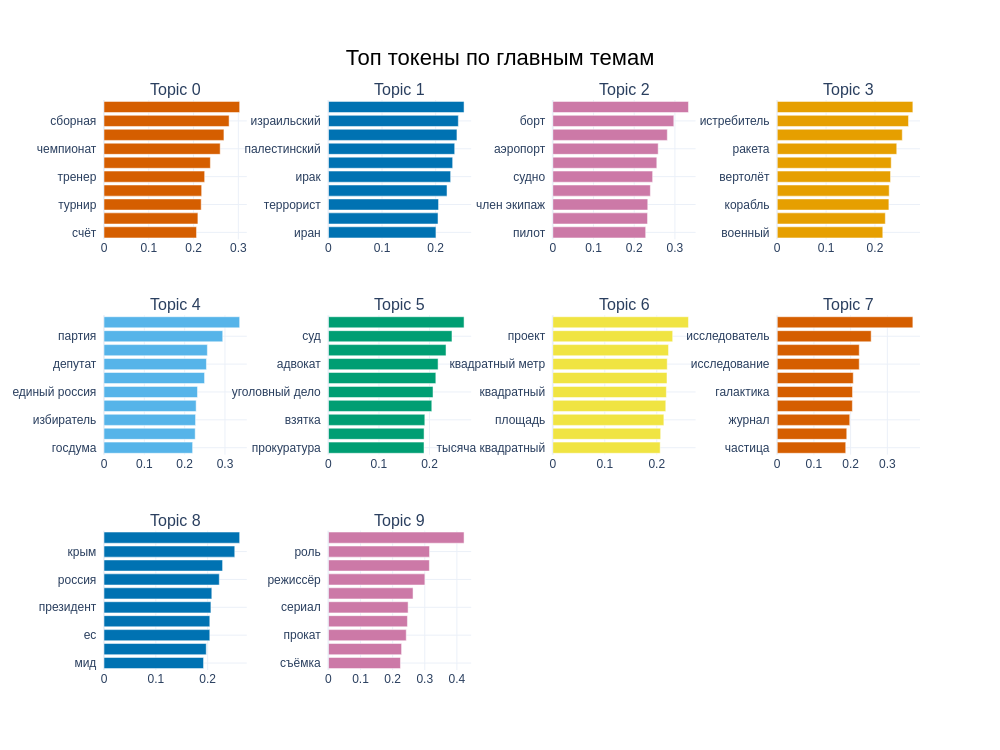

In [19]:
fig_barchart.write_image("tokens.png")

display(Image(filename="tokens.png"))

### Топики в 2D

Для визуализации взял 5к текстов, чтобы ниче не упало



In [20]:
fig_docs = topic_model.visualize_documents(docs_processed, embeddings=embeddings, sample=0.05, hide_annotations=True)
fig_docs.show()

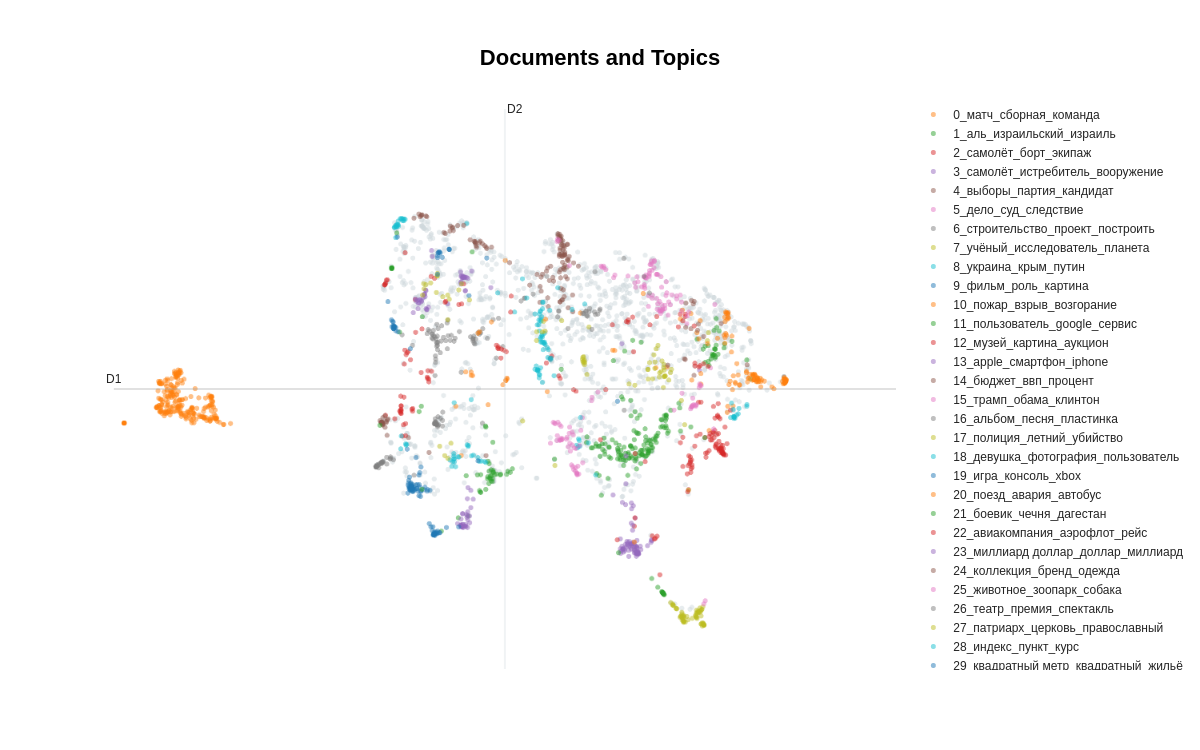

In [32]:
fig_docs.write_image("map.png")

display(Image(filename="map.png"))

В сектор `0` реально какая-то солянка, от спорта до каких-то денежных неустоек. Не знаю почему, но мне вспомнился мем https://share.google/bU5UmWakHwWqKVXac

### Распределение тем по токенам

In [34]:
doc_index = 10
print("Текст:", docs_raw[doc_index])

fig_dist = topic_model.visualize_distribution(probs[doc_index])
fig_dist.show()

Текст: В Киеве собралась четырежды разогнанная Рада 4 сентября Верховная Рада V созыва, которую четыре раза распустил президент Украины Виктор Ющенко, собралась на очередную сессию, сообщает "УНИАН". Спикер Александр Мороз заявил, что парламент будет работать до тех пор, пока не пройдут выборы и новые депутаты не получат мандаты.Юлии Тимошенко


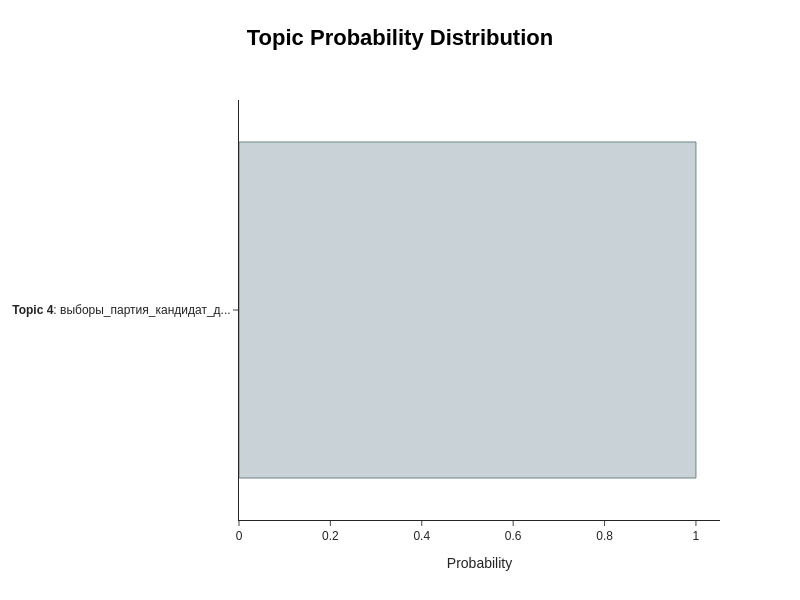

In [35]:
fig_dist.write_image("distribution1.png")

display(Image(filename="distribution1.png"))

Тут вроде все справедливо, модель сама уверена. Хотя как будто сюда напрашивается еще мультитопик

In [36]:
doc_index = 52
print("Текст:", docs_raw[doc_index])

fig_dist = topic_model.visualize_distribution(probs[doc_index])
fig_dist.show()

Текст: Счетная палата выявила нарушения при приватизации авиапарка "Домодедовскими авиалиниями" Счетная палата проверила авиакомпанию "Домодедовские авиалинии" и фактически вынесла обвинительный приговор ее новому руководству, назначенному год назад. Руководство "Домодедовских авиалиний" неправомерно приватизировало весь авиапарк компании - дословно говорится в сообщении Счетной палаты. Проверку авиакомпании Счетная палата проводила  в апреле – июле этого года. Проверка показала, что отсутствие действенного контроля со стороны государства в органах управления ОАО “ДАЛ” привело к нарушениях при приватизации имущества общества - отмечают в Счетной палате. Среди этих нарушений - нарушения в приватизации всего авиационного парка. Все это привело к тому, что стоимость основных средств авиакомпании снизилась с июля 2002 года по апрель 2003 года на 93 процента (с 289,1 до 20,6 миллионов рублей), а предприятие на правах аренды вынуждено эксплуатировать 18 воздушных судов.


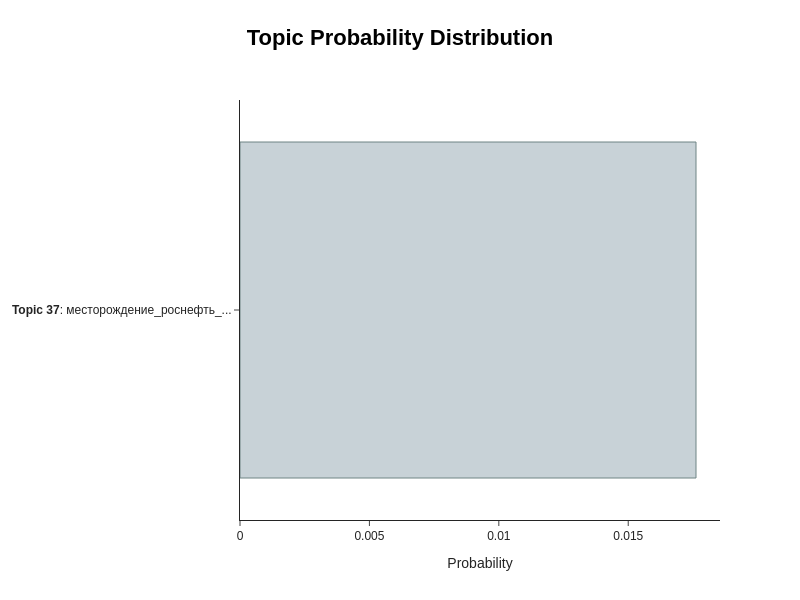

In [37]:
fig_dist.write_image("distribution2.png")

display(Image(filename="distribution2.png"))

Забавно что текст про разборки в авиалиниях попал в топик про нефть, НО модель сама не уверена, так как вероятность тут всего лишь 1,5%

In [38]:
doc_index = 100
print("Текст:", docs_raw[doc_index])

fig_dist = topic_model.visualize_distribution(probs[doc_index])
fig_dist.show()

Текст: Генштаб опроверг информацию об операции по освобождению Алеппо Начальник главного оперативного управления Генштаба генерал-лейтенант Сергей Рудской опроверг информацию о совместной операции России и Сирии по освобождению Алеппо. Об этом в понедельник, 11 апреля, сообщает РИА Новости. «Если не предотвратить эти действия террористов, то северные районы Сирии могут снова оказаться в блокаде. Поэтому все действия сирийских войск и российской авиации направлены на срыв планов бандформирований "Джебхат ан-Нусра" (запрещенная в России террористическая организация — прим. «Ленты.ру»)», — добавил он. Ранее, 10 апреля, премьер-министр Сирии Ваэль Надир аль-Хальки сообщил, что российские и сирийские военные готовят совместную операцию по освобождению Алеппо. Позднее в этот же день российский Центр по примирению враждующих сторон на территории Сирии сообщил, что севернее Алеппо обнаружено сосредоточение сил «Джебхат ан-Нусры». В населенных пунктах Мухэимхандрат, Джандуль, Храйтан и Кафр-Хам

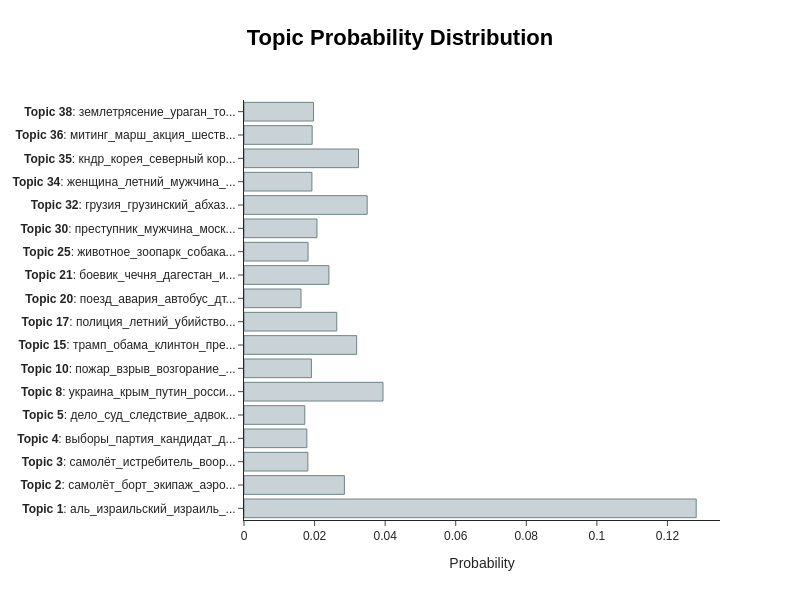

In [39]:
fig_dist.write_image("distribution3.png")

display(Image(filename="distribution3.png"))

Тут какая-то солянка топиков

и самая большая уверенность это топик про Израиль, хотя в тексте про Израль 0 упоминаний и только Сирия (ОКАК). Видимо тут по принципу близких регионов оно отнесло

Также есть топики, которые тоже совпадают по тем или иным причинам (геополитика, военные конфликты)

## Topic Diversity + UMass Coherence Hint

Исключим топик `-1`, так как это шум по сути

А для остальных топиков просто извлечем слова

In [40]:
topic_info = topic_model.get_topic_info()
topic_words = [
    [word for word, _ in topic_model.get_topic(topic)]
    for topic in topic_info['Topic'] if topic != -1
]

print(f"Извлечено слов для {len(topic_words)} топиков")

Извлечено слов для 43 топиков


Посчитаем разнообразность топиков

In [41]:
def calculate_topic_diversity(topic_words):
    if not topic_words:
        return 0
    all_words = [word for topic in topic_words for word in topic]
    unique_words = set(all_words)
    return len(unique_words) / len(all_words)

td = calculate_topic_diversity(topic_words)
print(f"Topic Diversity {td:.4f}")

Topic Diversity 0.9233


Тут работает принцип что чем ближе к 1, тем круче

92% ура!

Правда эта метрика же просто оценивает уникальность слов, а не смысловую составляющую, так что да

Токенезируем и построим словарь

In [42]:
tokenized_docs = [doc.split() for doc in docs_processed]
id2word = corpora.Dictionary(tokenized_docs)
corpus = [id2word.doc2bow(text) for text in tokenized_docs]

Считаем UMass Coherence Hint

In [43]:
coherence_model_umass = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=id2word,
    coherence='u_mass'
)

umass_score = coherence_model_umass.get_coherence()
print(f"UMass Coherence {umass_score:.4f}")

UMass Coherence -2.2782


Здесь у нас принцип что тем ближе к 0, тем лучше качество кластеров. То что минус это нормально

Метрика показывается связность слов в топиках и значение -2 вроде нормально